# FastDOCX vs python-docx — Benchmark

Measures median wall-clock time across 40 runs for four workloads:

| Workload      | Description                                  |
| ------------- | -------------------------------------------- |
| Paragraphs    | 500 plain paragraphs, alternating bold       |
| Headings      | 200 headings across levels 1–3               |
| Table         | 50×10 table with cell text                   |
| Open + append | Open a 100-paragraph file and append 50 more |


In [1]:
import os
import statistics
import tempfile
import time

RUNS = 40
PARA_COUNT = 500
HEADING_COUNT = 200
TABLE_ROWS = 50
TABLE_COLS = 10
OPEN_EXISTING_PARAS = 100
OPEN_APPEND_PARAS = 50

In [ ]:
def fastdocx_paragraphs(path):
    from fastdocx import Document

    doc = Document()
    for i in range(PARA_COUNT):
        doc.add_paragraph(f"Paragraph {i}", bold=i % 2 == 0)
    doc.save(path)


def fastdocx_headings(path):
    from fastdocx import Document

    doc = Document()
    for i in range(HEADING_COUNT):
        doc.add_heading(f"Heading {i}", level=(i % 3) + 1)
    doc.save(path)


def fastdocx_table(path):
    from fastdocx import Document

    doc = Document()
    table = doc.add_table(rows=TABLE_ROWS, cols=TABLE_COLS)
    for r in range(TABLE_ROWS):
        for c in range(TABLE_COLS):
            table[r, c].text = f"R{r}C{c}"
    doc.save(path)


def fastdocx_open_append(source_path, out_path):
    from fastdocx import Document

    doc = Document(source_path)
    for i in range(OPEN_APPEND_PARAS):
        doc.add_paragraph(f"Appended {i}")
    doc.save(out_path)


def pydocx_paragraphs(path):
    import docx

    doc = docx.Document()
    for i in range(PARA_COUNT):
        p = doc.add_paragraph(f"Paragraph {i}")
        if i % 2 == 0:
            p.runs[0].bold = True
    doc.save(path)


def pydocx_headings(path):
    import docx

    doc = docx.Document()
    for i in range(HEADING_COUNT):
        doc.add_heading(f"Heading {i}", level=(i % 3) + 1)
    doc.save(path)


def pydocx_table(path):
    import docx

    doc = docx.Document()
    table = doc.add_table(rows=TABLE_ROWS, cols=TABLE_COLS)
    for r in range(TABLE_ROWS):
        for c in range(TABLE_COLS):
            table.cell(r, c).text = f"R{r}C{c}"
    doc.save(path)


def pydocx_open_append(source_path, out_path):
    import docx

    doc = docx.Document(source_path)
    for i in range(OPEN_APPEND_PARAS):
        doc.add_paragraph(f"Appended {i}")
    doc.save(out_path)

In [ ]:
def time_workload(fn):
    times = []
    for _ in range(RUNS):
        with tempfile.NamedTemporaryFile(suffix=".docx", delete=True) as f:
            path = f.name
        t0 = time.perf_counter()
        fn(path)
        times.append((time.perf_counter() - t0) * 1000)  # ms
    return times


def time_open_workload(fn, source_path):
    times = []
    for _ in range(RUNS):
        with tempfile.NamedTemporaryFile(suffix=".docx", delete=True) as f:
            out_path = f.name
        t0 = time.perf_counter()
        fn(source_path, out_path)
        times.append((time.perf_counter() - t0) * 1000)  # ms
    return times


def build_fixture():
    import docx

    doc = docx.Document()
    for i in range(OPEN_EXISTING_PARAS):
        doc.add_paragraph(f"Existing paragraph {i}")
    with tempfile.NamedTemporaryFile(suffix=".docx", delete=False) as f:
        path = f.name
    doc.save(path)
    return path

In [ ]:
def _warmup():
    import docx

    from fastdocx import Document

    with tempfile.NamedTemporaryFile(suffix=".docx", delete=True) as f:
        path = f.name

    doc = Document()
    doc.add_paragraph("warmup")
    doc.save(path)

    pdoc = docx.Document()
    pdoc.add_paragraph("warmup")
    pdoc.save(path)

    print("Warmup complete.")


_warmup()


Warmup complete.


In [ ]:
print("Running benchmarks...")

fixture = build_fixture()
try:
    results = {
        "Paragraphs\n(500, alt. bold)": {
            "fastdocx": time_workload(fastdocx_paragraphs),
            "python-docx": time_workload(pydocx_paragraphs),
        },
        "Headings\n(200, levels 1-3)": {
            "fastdocx": time_workload(fastdocx_headings),
            "python-docx": time_workload(pydocx_headings),
        },
        "Table\n(50x10 cells)": {
            "fastdocx": time_workload(fastdocx_table),
            "python-docx": time_workload(pydocx_table),
        },
        "Open + append\n(100 existing, +50)": {
            "fastdocx": time_open_workload(fastdocx_open_append, fixture),
            "python-docx": time_open_workload(pydocx_open_append, fixture),
        },
    }
finally:
    os.unlink(fixture)

print(f"{'Workload':<35} {'fastdocx':>12} {'python-docx':>12} {'speedup':>10}")
print("-" * 72)
for label, times in results.items():
    fast = statistics.median(times["fastdocx"])
    slow = statistics.median(times["python-docx"])
    flat_label = label.replace("\n", " ")
    print(f"{flat_label:<35} {fast:>10.1f}ms {slow:>10.1f}ms {slow / fast:>9.1f}x")

Running benchmarks...


Workload                                fastdocx  python-docx    speedup
------------------------------------------------------------------------
Paragraphs (500, alt. bold)                4.0ms       36.3ms       9.0x
Headings (200, levels 1-3)                 1.5ms      108.6ms      73.6x
Table (50×10 cells)                        3.0ms     1938.5ms     638.2x
Open + append (100 existing, +50)          1.9ms       15.0ms       7.9x


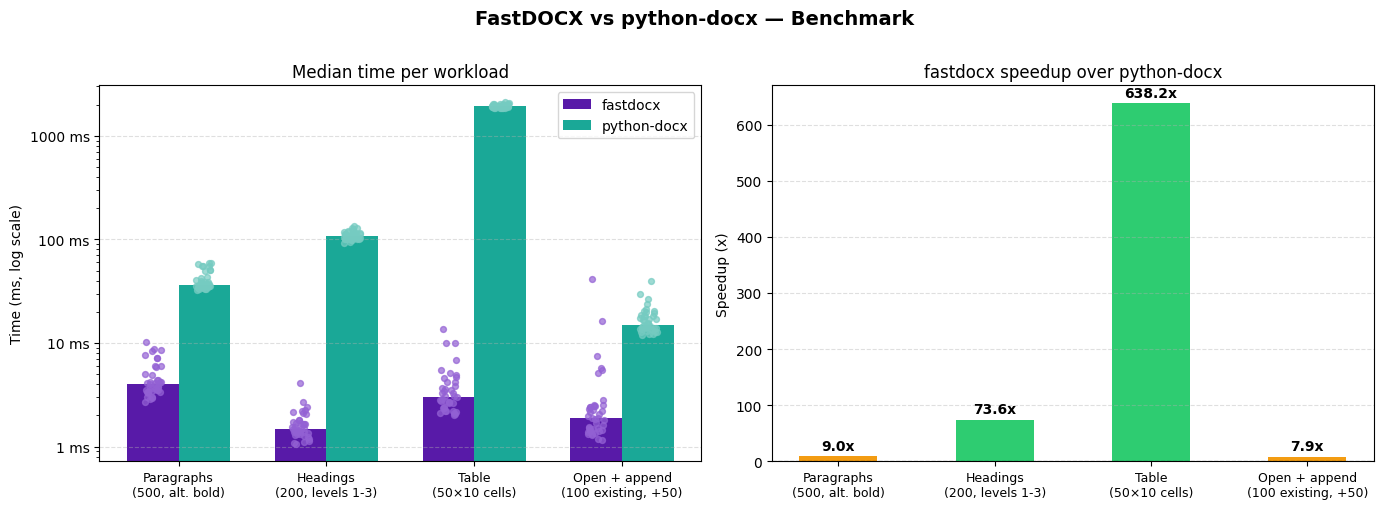

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

labels = list(results.keys())
fast_medians = [statistics.median(results[lable]["fastdocx"]) for lable in labels]
slow_medians = [statistics.median(results[lable]["python-docx"]) for lable in labels]
fast_all = [results[lable]["fastdocx"] for lable in labels]
slow_all = [results[lable]["python-docx"] for lable in labels]
speedups = [s / f for f, s in zip(fast_medians, slow_medians, strict=False)]

x = np.arange(len(labels))
bar_w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("FastDOCX vs python-docx — Benchmark", fontsize=14, fontweight="bold", y=1.01)

ax = axes[0]
bars_fast = ax.bar(x - bar_w / 2, fast_medians, bar_w, label="fastdocx", color="#581aa8")
bars_slow = ax.bar(x + bar_w / 2, slow_medians, bar_w, label="python-docx", color="#1aa897")

rng = np.random.default_rng(42)
for i, (fd, pd) in enumerate(zip(fast_all, slow_all, strict=False)):
    jitter = rng.uniform(-0.06, 0.06, size=len(fd))
    ax.scatter(i - bar_w / 2 + jitter, fd, color="#9361d4", s=18, zorder=3, alpha=0.7)
    jitter = rng.uniform(-0.06, 0.06, size=len(pd))
    ax.scatter(i + bar_w / 2 + jitter, pd, color="#75cbc1", s=18, zorder=3, alpha=0.7)

ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.4g} ms"))
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Time (ms, log scale)")
ax.set_title("Median time per workload")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

ax2 = axes[1]
colors = ["#2ecc71" if s >= 10 else "#f39c12" if s >= 3 else "#e74c3c" for s in speedups]
bars = ax2.bar(x, speedups, color=colors, width=0.5)

for bar, s in zip(bars, speedups, strict=False):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(speedups) * 0.01,
        f"{s:.1f}x",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel("Speedup (x)")
ax2.set_title("fastdocx speedup over python-docx")
ax2.axhline(1, color="black", linewidth=0.8, linestyle="--")
ax2.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

fastdocx   : 85.67 MB
python-docx: 2.20 MB


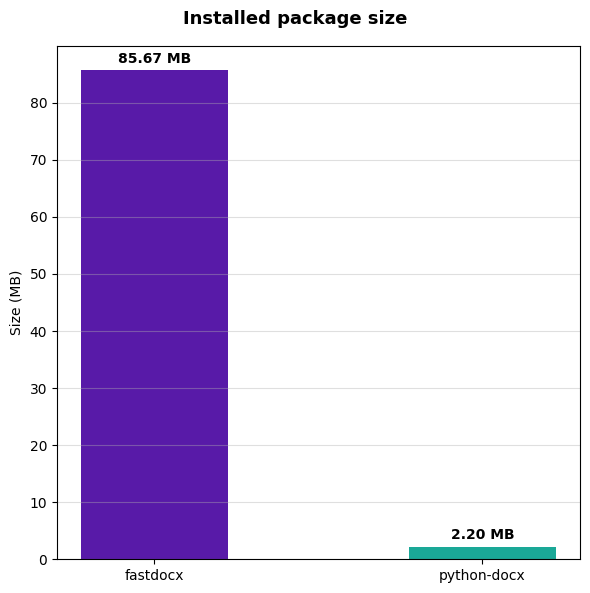

In [37]:
import importlib.util


def _dir_size_mb(path):
    total = sum(
        os.path.getsize(os.path.join(dp, f)) for dp, _, files in os.walk(path) for f in files
    )
    return total / 1024 / 1024


def _package_root(name):
    spec = importlib.util.find_spec(name)
    if spec and spec.origin:
        return os.path.dirname(spec.origin)
    raise ImportError(name)


fastdocx_size = _dir_size_mb(_package_root("fastdocx"))
pydocx_size = _dir_size_mb(_package_root("docx"))

print(f"fastdocx   : {fastdocx_size:.2f} MB")
print(f"python-docx: {pydocx_size:.2f} MB")

fig, ax = plt.subplots(figsize=(6, 6))
fig.suptitle("Installed package size", fontsize=13, fontweight="bold")

bars = ax.bar(
    ["fastdocx", "python-docx"],
    [fastdocx_size, pydocx_size],
    color=["#581aa8", "#1aa897"],
    width=0.45,
)
for bar, size in zip(bars, [fastdocx_size, pydocx_size], strict=False):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(fastdocx_size, pydocx_size) * 0.01,
        f"{size:.2f} MB",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.set_ylabel("Size (MB)")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()
